# Fraud Detection — Banking Transaction Data

**Key difference from churn prediction:** This dataset has **no ground-truth fraud labels**.
We tackle this with two complementary approaches:

| Approach | Method | Use when |
|----------|--------|----------|
| **A — Unsupervised** | Isolation Forest + LOF | No labels at all |
| **B — Supervised proxy** | Random Forest on rule-based labels | Domain rules available |

In production you would replace proxy labels with **verified fraud cases** from your case management system.

## 0. Setup & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Unsupervised
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Supervised
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.2

# Isolation Forest contamination — expected fraud rate (~1%)
IF_CONTAMINATION  = 0.01

# Rule-based proxy fraud thresholds (tune to your domain knowledge)
AMOUNT_ZSCORE_THRESHOLD = 4.0   # tx amount z-score above this = suspicious
NIGHT_HOURS             = (0, 4) # midnight–4 AM
VELOCITY_THRESHOLD      = 3     # >N txs same day from same customer
LOW_BALANCE_HIGH_TX     = 0.5   # tx > 50% of account balance

URL_INDIA   = 'https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv'
URL_FOREIGN = 'https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv'

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Preprocessing

In [2]:
df_india   = pd.read_csv(URL_INDIA)
df_foreign = pd.read_csv(URL_FOREIGN)
df_foreign = df_foreign.drop(columns=[c for c in ['Unnamed: 0', 'Age'] if c in df_foreign.columns])

df_india['source']   = 'india'
df_foreign['source'] = 'foreign'

df = pd.concat([df_india, df_foreign], ignore_index=True)
print(f'Combined shape: {df.shape}')

# ── Parse dates & time ────────────────────────────────────────────────────────
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB']     = pd.to_datetime(df['CustomerDOB'],     dayfirst=True, errors='coerce')

df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour'] = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')
df['TransactionMin']  = pd.to_numeric(df['TransactionTime'].str[2:4], errors='coerce')
df['DayOfWeek']       = df['TransactionDate'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend']      = df['DayOfWeek'].isin([5, 6]).astype(int)
df['TransactionMonth']= df['TransactionDate'].dt.month

snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

# Fix DOB century ambiguity
future_mask = df['CustomerDOB'] > snapshot_date
df.loc[future_mask, 'CustomerDOB'] -= pd.DateOffset(years=100)
df['Age'] = ((snapshot_date - df['CustomerDOB']).dt.days / 365.25).round(1)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

print('Preprocessing done.')
df[['TransactionDate','TransactionHour','is_weekend','Age']].head(3)

Combined shape: (1052151, 10)
Preprocessing done.


,TransactionDate,TransactionHour,is_weekend,Age
0,2016-08-02,14,0,22.8
1,2016-08-02,14,0,59.6
2,2016-08-02,14,0,19.9


## 2. Transaction-Level Feature Engineering
> All features are computed at the **transaction level** (one row = one transaction).
> This differs from the churn notebook where features were aggregated per customer.

In [3]:
# ── 2.1 Customer-level aggregates (used as context features per tx) ───────────
cust_stats = df.groupby('CustomerID').agg(
    cust_mean_tx  = ('TransactionAmount (INR)', 'mean'),
    cust_std_tx   = ('TransactionAmount (INR)', 'std'),
    cust_max_tx   = ('TransactionAmount (INR)', 'max'),
    cust_tx_count = ('TransactionID',           'count'),
).reset_index()
cust_stats['cust_std_tx'] = cust_stats['cust_std_tx'].fillna(0)

df = df.merge(cust_stats, on='CustomerID', how='left')

# ── 2.2 Amount z-score relative to that customer's history ────────────────────
df['tx_zscore'] = np.where(
    df['cust_std_tx'] > 0,
    (df['TransactionAmount (INR)'] - df['cust_mean_tx']) / df['cust_std_tx'],
    0
)

# ── 2.3 Transaction-to-balance ratio ──────────────────────────────────────────
df['tx_balance_ratio'] = np.where(
    df['CustAccountBalance'] > 0,
    df['TransactionAmount (INR)'] / df['CustAccountBalance'],
    0
)
df['tx_balance_ratio'] = df['tx_balance_ratio'].clip(upper=10)  # cap outliers

# ── 2.4 Velocity — how many txs same customer made that same day ───────────────
daily_velocity = df.groupby(['CustomerID', 'TransactionDate']).size().reset_index(name='daily_velocity')
df = df.merge(daily_velocity, on=['CustomerID', 'TransactionDate'], how='left')

# ── 2.5 Is night transaction ──────────────────────────────────────────────────
df['is_night'] = df['TransactionHour'].between(*NIGHT_HOURS).astype(int)

# ── 2.6 Log-transform amount ──────────────────────────────────────────────────
df['log_amount']  = np.log1p(df['TransactionAmount (INR)'])
df['log_balance'] = np.log1p(df['CustAccountBalance'].fillna(0))

print('Transaction-level features ready.')
print(df[['tx_zscore','tx_balance_ratio','daily_velocity','is_night']].describe().round(3))

Transaction-level features ready.
         tx_zscore  tx_balance_ratio  daily_velocity     is_night
count  1052151.000       1052151.000     1052151.000  1052151.000
mean        -0.000             0.612           1.014        0.040
std          0.396             1.993           0.118        0.195
min         -1.739             0.000           1.000        0.000
25%          0.000             0.006           1.000        0.000
50%          0.000             0.025           1.000        0.000
75%          0.000             0.118           1.000        0.000
max          2.040            10.000           4.000        1.000


## 3. Proxy Fraud Labels (Rule-Based)
> Since there are no verified fraud labels, we build a **conservative rule set** to flag suspicious transactions.
> These rules become the supervision signal for Approach B.
> **Replace with real labels in production.**

In [4]:
# Rule 1: Amount z-score extremely high relative to customer's own history
rule_amount_spike = df['tx_zscore'] > AMOUNT_ZSCORE_THRESHOLD

# Rule 2: Night-time transaction (midnight – 4 AM)
rule_night = df['is_night'] == 1

# Rule 3: Same-day transaction velocity above threshold
rule_velocity = df['daily_velocity'] > VELOCITY_THRESHOLD

# Rule 4: Transaction exceeds a large proportion of account balance
rule_balance_drain = df['tx_balance_ratio'] > LOW_BALANCE_HIGH_TX

# Rule 5: Globally extreme transaction amount (top 0.5%)
amount_p995 = df['TransactionAmount (INR)'].quantile(0.995)
rule_extreme_amount = df['TransactionAmount (INR)'] > amount_p995

# Flag = suspicious if ANY two or more rules fire (reduces false positives)
rule_scores = (
    rule_amount_spike.astype(int) +
    rule_night.astype(int) +
    rule_velocity.astype(int) +
    rule_balance_drain.astype(int) +
    rule_extreme_amount.astype(int)
)
df['rule_flags']   = rule_scores
df['proxy_fraud']  = (rule_scores >= 2).astype(int)

fraud_rate = df['proxy_fraud'].mean() * 100
print(f'Proxy fraud rate : {fraud_rate:.2f}%  ({df["proxy_fraud"].sum():,} of {len(df):,} transactions)')
print(f'\nRule activation rates:')
print(f'  Amount spike  : {rule_amount_spike.mean()*100:.2f}%')
print(f'  Night tx      : {rule_night.mean()*100:.2f}%')
print(f'  High velocity : {rule_velocity.mean()*100:.2f}%')
print(f'  Balance drain : {rule_balance_drain.mean()*100:.2f}%')
print(f'  Extreme amount: {rule_extreme_amount.mean()*100:.2f}%')

Proxy fraud rate : 0.80%  (8,459 of 1,052,151 transactions)

Rule activation rates:
  Amount spike  : 0.00%
  Night tx      : 3.98%
  High velocity : 0.00%
  Balance drain : 12.87%
  Extreme amount: 0.50%


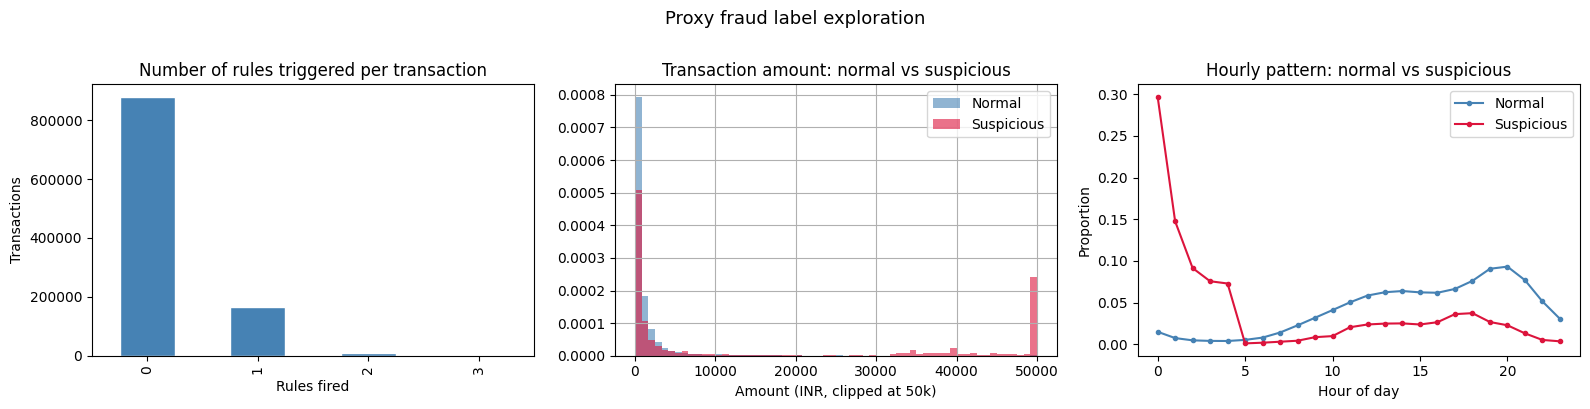

In [5]:
# Visualise rule overlap
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram of rule flag count per transaction
df['rule_flags'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Number of rules triggered per transaction')
axes[0].set_xlabel('Rules fired')
axes[0].set_ylabel('Transactions')

# Amount distribution: fraud vs normal
df[df['proxy_fraud']==0]['TransactionAmount (INR)'].clip(upper=50000).hist(
    bins=60, ax=axes[1], alpha=0.6, color='steelblue', label='Normal', density=True
)
df[df['proxy_fraud']==1]['TransactionAmount (INR)'].clip(upper=50000).hist(
    bins=60, ax=axes[1], alpha=0.6, color='crimson', label='Suspicious', density=True
)
axes[1].set_title('Transaction amount: normal vs suspicious')
axes[1].set_xlabel('Amount (INR, clipped at 50k)')
axes[1].legend()

# Hourly distribution
for label, color, name in [(0,'steelblue','Normal'), (1,'crimson','Suspicious')]:
    hour_dist = df[df['proxy_fraud']==label]['TransactionHour'].value_counts().sort_index()
    hour_dist_norm = hour_dist / hour_dist.sum()
    axes[2].plot(hour_dist_norm.index, hour_dist_norm.values, color=color, label=name, marker='o', ms=3)
axes[2].set_title('Hourly pattern: normal vs suspicious')
axes[2].set_xlabel('Hour of day')
axes[2].set_ylabel('Proportion')
axes[2].legend()

plt.suptitle('Proxy fraud label exploration', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fraud_label_eda.png', dpi=150)
plt.show()

## 4A. Unsupervised Approach — Isolation Forest + LOF
> No labels needed. Anomaly scores are computed purely from feature patterns.

In [6]:
UNSUP_FEATURES = [
    'log_amount', 'log_balance', 'tx_zscore', 'tx_balance_ratio',
    'daily_velocity', 'is_night', 'is_weekend',
    'TransactionHour', 'DayOfWeek'
]

X_unsup = df[UNSUP_FEATURES].copy().fillna(df[UNSUP_FEATURES].median())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

# ── Isolation Forest ──────────────────────────────────────────────────────────
iso = IsolationForest(
    contamination = IF_CONTAMINATION,
    n_estimators  = 200,
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)
df['if_score']  = iso.fit_predict(X_scaled)       # -1 = anomaly, 1 = normal
df['if_anomaly']= (df['if_score'] == -1).astype(int)

# Raw anomaly score (lower = more anomalous)
df['if_raw_score'] = iso.decision_function(X_scaled)

print(f'Isolation Forest flagged: {df["if_anomaly"].sum():,}  ({df["if_anomaly"].mean()*100:.2f}%)')

Isolation Forest flagged: 10,522  (1.00%)


In [7]:
# ── Local Outlier Factor ───────────────────────────────────────────────────────
# LOF is slow on large data — sample 100k rows if dataset is big
SAMPLE_SIZE = min(100_000, len(df))
sample_idx  = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index

lof = LocalOutlierFactor(
    n_neighbors   = 20,
    contamination = IF_CONTAMINATION,
    n_jobs        = -1
)
lof_preds = lof.fit_predict(X_scaled[df.index.isin(sample_idx)])

df['lof_anomaly'] = 0
df.loc[sample_idx, 'lof_anomaly'] = (lof_preds == -1).astype(int)

print(f'LOF flagged (on sample): {df["lof_anomaly"].sum():,}  ({df.loc[sample_idx, "lof_anomaly"].mean()*100:.2f}%)')

# Agreement between the two methods
df['both_flag'] = ((df['if_anomaly'] == 1) & (df['lof_anomaly'] == 1)).astype(int)
print(f'\nBoth methods agree: {df["both_flag"].sum():,} transactions')

LOF flagged (on sample): 1,000  (1.00%)

Both methods agree: 6 transactions


In [8]:
# Evaluate unsupervised flags vs proxy labels
print('Isolation Forest vs proxy labels:')
print(classification_report(df['proxy_fraud'], df['if_anomaly'],
                             target_names=['Normal','Anomaly']))

print('LOF vs proxy labels (on sample):')
print(classification_report(
    df.loc[sample_idx, 'proxy_fraud'],
    df.loc[sample_idx, 'lof_anomaly'],
    target_names=['Normal','Anomaly']
))

Isolation Forest vs proxy labels:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99   1043692
     Anomaly       0.36      0.45      0.40      8459

    accuracy                           0.99   1052151
   macro avg       0.68      0.72      0.70   1052151
weighted avg       0.99      0.99      0.99   1052151

LOF vs proxy labels (on sample):
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     99212
     Anomaly       0.01      0.01      0.01       788

    accuracy                           0.98    100000
   macro avg       0.50      0.50      0.50    100000
weighted avg       0.98      0.98      0.98    100000



## 4B. Supervised Approach — Random Forest on Proxy Labels
> Uses the rule-based labels as supervision. Learns *patterns* beyond the rules themselves.

In [9]:
SUP_FEATURES = [
    'log_amount', 'log_balance',
    'tx_zscore', 'tx_balance_ratio',
    'daily_velocity', 'cust_tx_count',
    'is_night', 'is_weekend',
    'TransactionHour', 'DayOfWeek', 'TransactionMonth',
    'Age'
]

X_sup = df[SUP_FEATURES].fillna(df[SUP_FEATURES].median())
y_sup = df['proxy_fraud']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sup, y_sup,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y_sup
)

rf = RandomForestClassifier(
    n_estimators  = 300,
    max_depth     = 12,
    min_samples_leaf = 10,
    class_weight  = 'balanced',   # handles class imbalance
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pr_auc = cross_val_score(rf, X_tr, y_tr, cv=cv, scoring='average_precision', n_jobs=-1)
print(f'CV PR-AUC: {cv_pr_auc.mean():.4f} ± {cv_pr_auc.std():.4f}')

rf.fit(X_tr, y_tr)
y_prob = rf.predict_proba(X_te)[:, 1]

print(f'Test ROC-AUC : {roc_auc_score(y_te, y_prob):.4f}')
print(f'Test PR-AUC  : {average_precision_score(y_te, y_prob):.4f}')

CV PR-AUC: 1.0000 ± 0.0000
Test ROC-AUC : 1.0000
Test PR-AUC  : 1.0000


## 5. Evaluation & Threshold Tuning
> For fraud, **Precision-Recall AUC is more informative than ROC-AUC** because the class is heavily imbalanced.

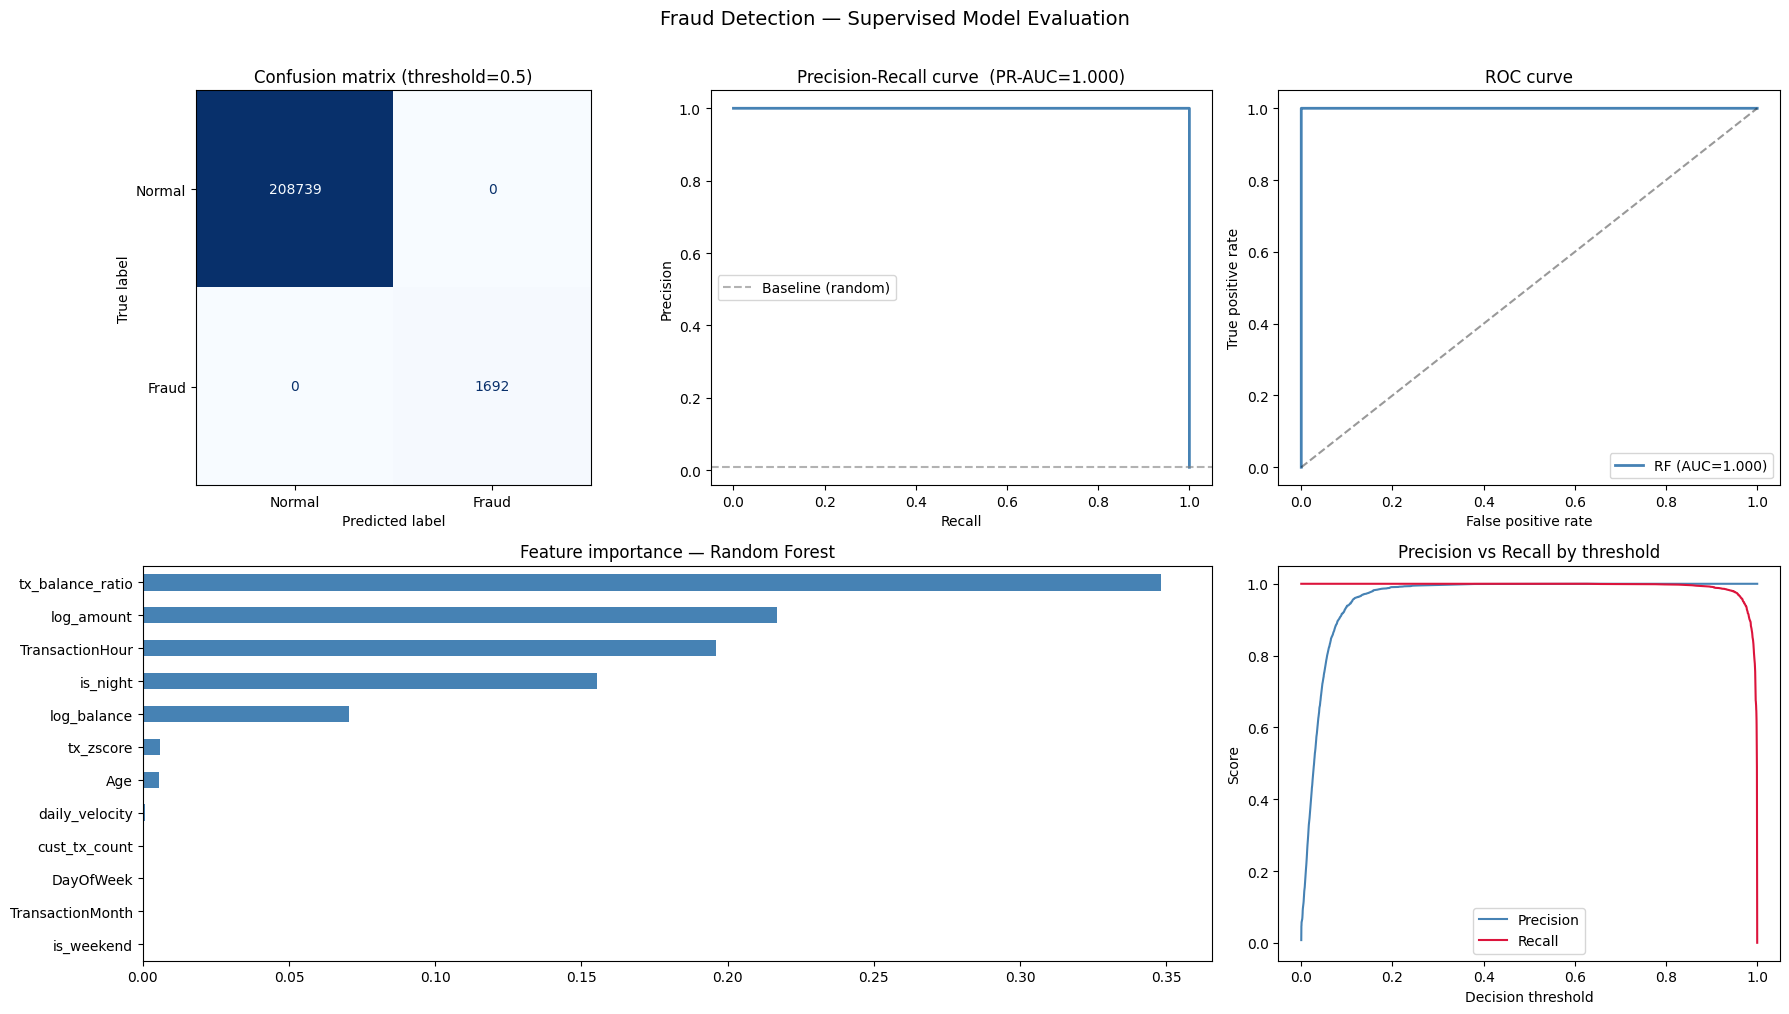

In [10]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── 1. Confusion matrix (threshold=0.5) ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
y_pred_default = (y_prob >= 0.5).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred_default),
    display_labels=['Normal', 'Fraud']
).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion matrix (threshold=0.5)')

# ── 2. Precision-Recall curve ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
prec, rec, thresholds = precision_recall_curve(y_te, y_prob)
ax2.plot(rec, prec, color='steelblue', lw=2)
ax2.axhline(y_te.mean(), color='gray', linestyle='--', alpha=0.6, label='Baseline (random)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall curve  (PR-AUC={average_precision_score(y_te, y_prob):.3f})')
ax2.legend()

# ── 3. ROC curve ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax3.plot(fpr, tpr, color='steelblue', lw=2, label=f'RF (AUC={roc_auc_score(y_te, y_prob):.3f})')
ax3.plot([0,1],[0,1],'k--', alpha=0.4)
ax3.set_xlabel('False positive rate')
ax3.set_ylabel('True positive rate')
ax3.set_title('ROC curve')
ax3.legend()

# ── 4. Feature importance ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
importances = pd.Series(rf.feature_importances_, index=SUP_FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', ax=ax4, color='steelblue')
ax4.set_title('Feature importance — Random Forest')

# ── 5. Threshold vs Precision / Recall tradeoff ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(thresholds, prec[:-1], label='Precision', color='steelblue')
ax5.plot(thresholds, rec[:-1],  label='Recall',    color='crimson')
ax5.set_xlabel('Decision threshold')
ax5.set_ylabel('Score')
ax5.set_title('Precision vs Recall by threshold')
ax5.legend()

plt.suptitle('Fraud Detection — Supervised Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fraud_evaluation.png', dpi=150)
plt.show()

In [11]:
# ── Find optimal threshold for F2 score (weights recall 2x over precision) ────
# In fraud, missing a fraud (false negative) is worse than a false alarm.
from sklearn.metrics import fbeta_score

best_thresh, best_f2 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    f2 = fbeta_score(y_te, (y_prob >= t).astype(int), beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2, best_thresh = f2, t

print(f'Optimal threshold (F2): {best_thresh:.2f}  —  F2={best_f2:.4f}')
y_pred_tuned = (y_prob >= best_thresh).astype(int)
print()
print(classification_report(y_te, y_pred_tuned, target_names=['Normal', 'Fraud']))

Optimal threshold (F2): 0.38  —  F2=1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    208739
       Fraud       1.00      1.00      1.00      1692

    accuracy                           1.00    210431
   macro avg       1.00      1.00      1.00    210431
weighted avg       1.00      1.00      1.00    210431



## 6. Score All Transactions & Compare Approaches

In [12]:
# Score full dataset with supervised model
X_all_sup = df[SUP_FEATURES].fillna(df[SUP_FEATURES].median())
df['rf_fraud_prob']  = rf.predict_proba(X_all_sup)[:, 1]
df['rf_fraud_flag']  = (df['rf_fraud_prob'] >= best_thresh).astype(int)

# Combine signals into a final risk score
# Weighted sum: RF model (primary) + Isolation Forest (secondary) + both-agree bonus
df['combined_risk'] = (
    0.60 * df['rf_fraud_prob'] +
    0.30 * df['if_anomaly'] +
    0.10 * df['both_flag']
)

def risk_tier(p):
    if p >= 0.75: return 'Critical'
    if p >= 0.50: return 'High'
    if p >= 0.25: return 'Medium'
    return 'Low'

df['risk_tier'] = df['combined_risk'].apply(risk_tier)

print('Combined risk tier distribution:')
print(df['risk_tier'].value_counts().to_string())

print(f'\nOverlap — RF + IF both flag:          {((df["rf_fraud_flag"]==1) & (df["if_anomaly"]==1)).sum():,}')
print(f'Only RF flags:                         {((df["rf_fraud_flag"]==1) & (df["if_anomaly"]==0)).sum():,}')
print(f'Only IF flags:                         {((df["rf_fraud_flag"]==0) & (df["if_anomaly"]==1)).sum():,}')

Combined risk tier distribution:
risk_tier
Low         1036979
Medium         6717
High           4648
Critical       3807

Overlap — RF + IF both flag:          3,810
Only RF flags:                         4,651
Only IF flags:                         6,712


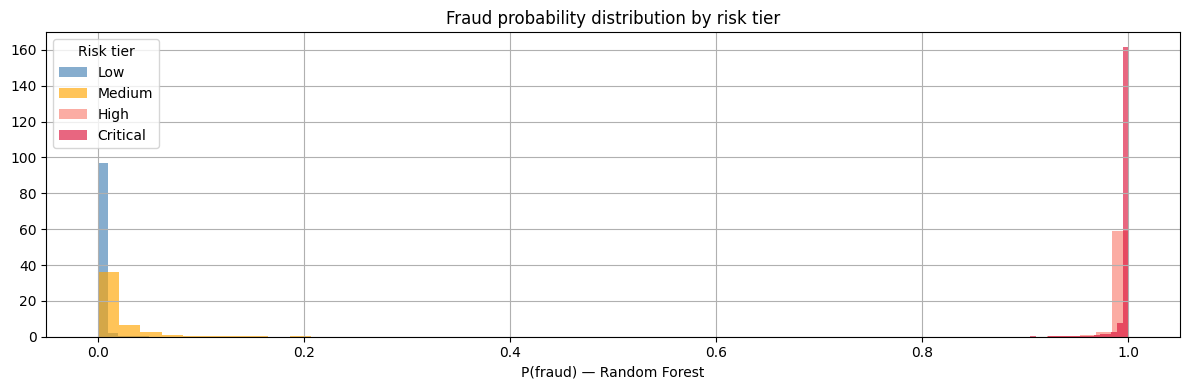

In [13]:
# Anomaly score distribution by risk tier
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'Low': 'steelblue', 'Medium': 'orange', 'High': 'salmon', 'Critical': 'crimson'}
for tier, color in colors.items():
    subset = df[df['risk_tier'] == tier]['rf_fraud_prob']
    if len(subset): subset.hist(bins=40, ax=ax, alpha=0.65, color=color, label=tier, density=True)
ax.set_title('Fraud probability distribution by risk tier')
ax.set_xlabel('P(fraud) — Random Forest')
ax.legend(title='Risk tier')
plt.tight_layout()
plt.savefig('fraud_risk_distribution.png', dpi=150)
plt.show()

## 7. Deep Dive — What Do Flagged Transactions Look Like?

In [14]:
critical = df[df['risk_tier'] == 'Critical']
normal   = df[df['risk_tier'] == 'Low']

compare_cols = [
    'TransactionAmount (INR)', 'CustAccountBalance',
    'tx_zscore', 'tx_balance_ratio', 'daily_velocity',
    'TransactionHour', 'is_night', 'Age'
]

comparison = pd.DataFrame({
    'Low risk (mean)':      normal[compare_cols].mean(),
    'Critical risk (mean)': critical[compare_cols].mean(),
}).round(2)
comparison['ratio'] = (comparison['Critical risk (mean)'] / comparison['Low risk (mean)'].replace(0, np.nan)).round(2)

print('Profile comparison — Critical vs Low risk transactions:')
print(comparison.to_string())

Profile comparison — Critical vs Low risk transactions:
                         Low risk (mean)  Critical risk (mean)  ratio
TransactionAmount (INR)          1393.28               5020.20   3.60
CustAccountBalance             117261.00              12835.91   0.11
tx_zscore                          -0.00                 -0.01    NaN
tx_balance_ratio                    0.56                  6.00  10.71
daily_velocity                      1.01                  1.04   1.03
TransactionHour                    15.54                  1.55   0.10
is_night                            0.03                  0.98  32.67
Age                                31.41                 28.40   0.90


## 8. Export — Alert List

In [15]:
alert_cols = [
    'TransactionID', 'CustomerID', 'TransactionDate', 'TransactionHour',
    'TransactionAmount (INR)', 'CustAccountBalance',
    'tx_zscore', 'daily_velocity', 'is_night',
    'if_anomaly', 'rf_fraud_prob', 'combined_risk', 'risk_tier'
]

alerts = df[df['risk_tier'].isin(['Critical', 'High'])].sort_values(
    'combined_risk', ascending=False
)[alert_cols]

alerts.to_csv('fraud_alert_list.csv', index=False)
print(f'Alerts exported: {len(alerts):,} transactions')
print(f'  Critical : {(alerts["risk_tier"]=="Critical").sum():,}')
print(f'  High     : {(alerts["risk_tier"]=="High").sum():,}')
print('Saved → fraud_alert_list.csv')
alerts.head(10)

Alerts exported: 8,455 transactions
  Critical : 3,807
  High     : 4,648
Saved → fraud_alert_list.csv


,TransactionID,CustomerID,TransactionDate,TransactionHour,TransactionAmount (INR),CustAccountBalance,tx_zscore,daily_velocity,is_night,if_anomaly,rf_fraud_prob,combined_risk,risk_tier
151312,T151313,C2631338,2016-08-04,0,575.00,7.86,0.707107,1,1,1,0.999966,0.999979,Critical
194936,T194937,C8438832,2016-08-08,0,4267.00,452.70,0.000000,1,1,1,0.999801,0.999881,Critical
456375,T456376,C3514316,2016-08-21,0,806.52,84.92,0.707107,1,1,1,0.999982,0.899989,Critical
132789,T132790,C2924213,2016-08-05,0,2364.00,56.54,0.000000,1,1,1,0.999981,0.899989,Critical
1035132,T1035133,C7723070,2016-09-13,0,1253.84,2.50,0.707107,1,1,1,0.999981,0.899988,Critical
218694,T218695,C5029226,2016-08-07,0,413.00,34.66,0.707107,1,1,1,0.999979,0.899988,Critical
37020,T37021,C8013032,2016-09-27,1,1169.00,113.84,0.707107,1,1,1,0.999978,0.899987,Critical
857217,T857218,C6118863,2016-09-08,0,2982.00,90.04,0.000000,1,1,1,0.999975,0.899985,Critical
726353,T726354,C6024949,2016-09-02,3,1500.00,24.47,0.707107,1,1,1,0.999975,0.899985,Critical
850942,T850943,C6935189,2016-09-09,4,1520.00,79.48,0.707107,1,1,1,0.999975,0.899985,Critical


## 9. Summary

| | Approach A — Unsupervised | Approach B — Supervised |
|---|---|---|
| **Method** | Isolation Forest + LOF | Random Forest on proxy labels |
| **Requires labels?** | No | Proxy rules (or real labels) |
| **Best for** | Cold start, exploratory | When rules/labels available |
| **Key metric** | Anomaly score | PR-AUC, F2-score |
| **Class imbalance** | Handled via `contamination` | `class_weight='balanced'` |
| **Output** | Binary flag | Probability score |

**Final risk score** = 0.60 × RF prob + 0.30 × IF flag + 0.10 × both-agree bonus

### Next Steps
- **Get real labels** — review the Critical/High alerts manually; confirmed cases become training data
- **Add XGBoost** with `scale_pos_weight` for better handling of severe imbalance
- **Graph features** — build customer–location or customer–device networks; fraud often clusters in rings
- **SHAP values** — explain individual transaction flags to analysts
- **Concept drift monitoring** — retrain monthly as fraud patterns evolve
- **Feedback loop** — feed analyst verdicts back into supervised model retraining